# Imports

In [4]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' # 0: All, 1: Info, 2: Warnings, 3: Errors only
os.environ['TF_XLA_FLAGS'] = '--tf_xla_enable_xla_devices=false'

import numpy as np
import pandas as pd
import os, shutil, cv2, warnings

import seaborn as sns

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from PIL import Image

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Dense, Conv2D, InputLayer, Reshape, MaxPooling2D, Flatten, Dropout, BatchNormalization, Input, GlobalAveragePooling2D, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input


warnings.filterwarnings('ignore')

from tensorflow.keras.layers import Input# Setting up and checking dataset

In [11]:
img_path= "/home/groggy/data/a-large-scale-fish-dataset/2/Fish_Dataset/Fish_Dataset"

In [12]:
labels = [
    label for label in os.listdir(img_path)
    if not label.endswith("GT") and os.path.isdir(os.path.join(img_path, label))
]

print(labels)

['Striped Red Mullet', 'Black Sea Sprat', 'Shrimp', 'Gilt-Head Bream', 'Red Sea Bream', 'Trout', 'Hourse Mackerel', 'Sea Bass', 'Red Mullet']


In [13]:
img_list = []
label_list = []

# 1. Top level folder /labels
labels = [d for d in os.listdir(img_path)
          if os.path.isdir(os.path.join(img_path, d))]

for label in labels:

    label_path = os.path.join(img_path, label)

    # 2. traverse subfolders inside each labels
    for subfolder in os.listdir(label_path):

        sub_path = os.path.join(label_path, subfolder)

        # skip non-folders- and folders ending with GT
        if not os.path.isdir(sub_path):
            continue

        if subfolder.endswith("GT"):
            continue

        # 3. Important: Only select the subfolder whose name matches the label
        if subfolder != label:
            continue

        # 4. Read images
        for img_file in os.listdir(sub_path):
            if img_file.lower().endswith(('.png', '.jpg', '.jpeg')):
                img_list.append(os.path.join(sub_path, img_file))
                label_list.append(label)

print("Total images:", len(img_list))
print("Total Classes:", len(set(label_list)))

Toplam resim: 9000
Sınıf sayısı: 9


In [14]:
print(len(img_list))
print(len(label_list))
print(img_list[:5])
print(label_list[:5])

9000
9000
['/home/groggy/data/a-large-scale-fish-dataset/2/Fish_Dataset/Fish_Dataset/Striped Red Mullet/Striped Red Mullet/00599.png', '/home/groggy/data/a-large-scale-fish-dataset/2/Fish_Dataset/Fish_Dataset/Striped Red Mullet/Striped Red Mullet/00304.png', '/home/groggy/data/a-large-scale-fish-dataset/2/Fish_Dataset/Fish_Dataset/Striped Red Mullet/Striped Red Mullet/00472.png', '/home/groggy/data/a-large-scale-fish-dataset/2/Fish_Dataset/Fish_Dataset/Striped Red Mullet/Striped Red Mullet/00663.png', '/home/groggy/data/a-large-scale-fish-dataset/2/Fish_Dataset/Fish_Dataset/Striped Red Mullet/Striped Red Mullet/00543.png']
['Striped Red Mullet', 'Striped Red Mullet', 'Striped Red Mullet', 'Striped Red Mullet', 'Striped Red Mullet']


In [15]:
df = pd.DataFrame(list(zip(img_list, label_list)), columns=['img','label'])

In [16]:
d = {label: i for i, label in enumerate(labels)}

In [17]:
df['label_encoded']=df['label'].map(d)

In [18]:
df

,img,label,label_encoded
0,/home/groggy/data/a-large-scale-fish-dataset/2...,Striped Red Mullet,0
1,/home/groggy/data/a-large-scale-fish-dataset/2...,Striped Red Mullet,0
2,/home/groggy/data/a-large-scale-fish-dataset/2...,Striped Red Mullet,0
3,/home/groggy/data/a-large-scale-fish-dataset/2...,Striped Red Mullet,0
4,/home/groggy/data/a-large-scale-fish-dataset/2...,Striped Red Mullet,0
...,...,...,...
8995,/home/groggy/data/a-large-scale-fish-dataset/2...,Red Mullet,8
8996,/home/groggy/data/a-large-scale-fish-dataset/2...,Red Mullet,8
8997,/home/groggy/data/a-large-scale-fish-dataset/2...,Red Mullet,8
8998,/home/groggy/data/a-large-scale-fish-dataset/2...,Red Mullet,8


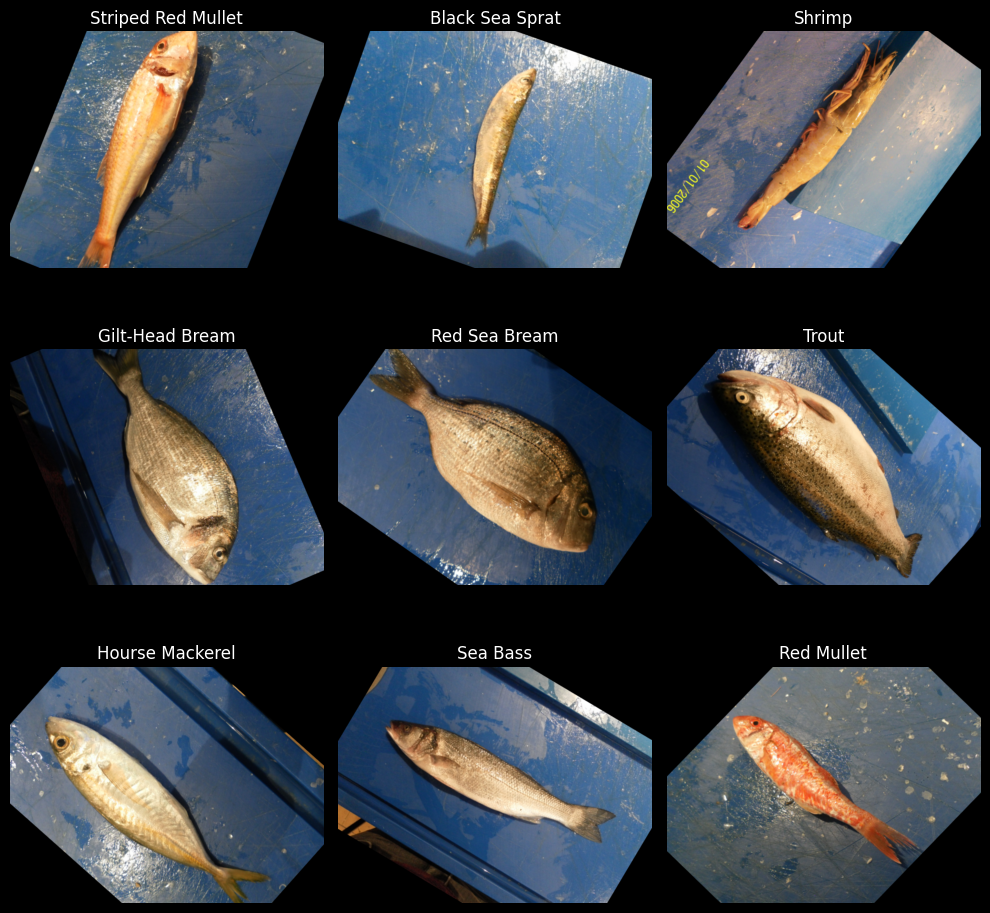

In [19]:
images = []

for label in labels:
    temp = df[df['label'] == label]

    if len(temp) == 0:
        print(f"Empy label: {label}")
        continue

    img_path = temp['img'].iloc[0]
    image = Image.open(img_path)
    images.append((image, label))

# Dynamic subplot
n = len(images)

plt.figure(figsize=(10, 10))

for i, (image, label) in enumerate(images):
    plt.subplot(3, 3, i + 1)
    plt.imshow(image)
    plt.title(label)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [20]:
df["label"].value_counts()

label
Striped Red Mullet    1000
Black Sea Sprat       1000
Shrimp                1000
Gilt-Head Bream       1000
Red Sea Bream         1000
Trout                 1000
Hourse Mackerel       1000
Sea Bass              1000
Red Mullet            1000
Name: count, dtype: int64

In [21]:
x = []

for img_path in df['img']:

    img = cv2.imread(img_path)

    if img is None:
        print("Couldn't load image:", img_path)
        continue

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (32, 32))
    img = img.astype('float32') / 255.0

    x.append(img)

# CNN model

In [22]:
x = np.array(x)

In [23]:
y=df[['label_encoded']]

In [24]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=.2,random_state=42)

In [25]:
df

,img,label,label_encoded
0,/home/groggy/data/a-large-scale-fish-dataset/2...,Striped Red Mullet,0
1,/home/groggy/data/a-large-scale-fish-dataset/2...,Striped Red Mullet,0
2,/home/groggy/data/a-large-scale-fish-dataset/2...,Striped Red Mullet,0
3,/home/groggy/data/a-large-scale-fish-dataset/2...,Striped Red Mullet,0
4,/home/groggy/data/a-large-scale-fish-dataset/2...,Striped Red Mullet,0
...,...,...,...
8995,/home/groggy/data/a-large-scale-fish-dataset/2...,Red Mullet,8
8996,/home/groggy/data/a-large-scale-fish-dataset/2...,Red Mullet,8
8997,/home/groggy/data/a-large-scale-fish-dataset/2...,Red Mullet,8
8998,/home/groggy/data/a-large-scale-fish-dataset/2...,Red Mullet,8


In [26]:
cnn_model = Sequential()

cnn_model.add(Input(shape=(32,32,3)))

cnn_model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
cnn_model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
cnn_model.add(BatchNormalization())
cnn_model.add(MaxPooling2D((2,2)))
cnn_model.add(Dropout(0.25))

cnn_model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
cnn_model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
cnn_model.add(BatchNormalization())
cnn_model.add(MaxPooling2D((2,2)))
cnn_model.add(Dropout(0.25))

cnn_model.add(Conv2D(256, (3,3), activation='relu', padding='same'))
cnn_model.add(BatchNormalization())
cnn_model.add(MaxPooling2D((2,2)))
cnn_model.add(Dropout(0.25))

cnn_model.add(Flatten())

cnn_model.add(Dense(256, activation='relu'))
cnn_model.add(Dropout(0.5))

cnn_model.add(Dense(25, activation='softmax'))

cnn_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [27]:
early_stop = EarlyStopping(monitor='val_loss',patience=3,restore_best_weights=True)

In [28]:
history_cnn = cnn_model.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs=10,
    batch_size=8,
    callbacks=[early_stop]
)

Epoch 1/10
900/900 ━━━━━━━━━━━━━━━━━━━━ 42s 44ms/step - accuracy: 0.3514 - loss: 1.9975 - val_accuracy: 0.4706 - val_loss: 1.3492
Epoch 2/10
900/900 ━━━━━━━━━━━━━━━━━━━━ 39s 43ms/step - accuracy: 0.5011 - loss: 1.3934 - val_accuracy: 0.5506 - val_loss: 1.2034
Epoch 3/10
900/900 ━━━━━━━━━━━━━━━━━━━━ 68s 76ms/step - accuracy: 0.5644 - loss: 1.2027 - val_accuracy: 0.4972 - val_loss: 1.4185
Epoch 4/10
900/900 ━━━━━━━━━━━━━━━━━━━━ 90s 100ms/step - accuracy: 0.6453 - loss: 1.0071 - val_accuracy: 0.7128 - val_loss: 0.9154
Epoch 5/10
900/900 ━━━━━━━━━━━━━━━━━━━━ 38s 42ms/step - accuracy: 0.7161 - loss: 0.8109 - val_accuracy: 0.8039 - val_loss: 0.6220
Epoch 6/10
900/900 ━━━━━━━━━━━━━━━━━━━━ 39s 43ms/step - accuracy: 0.7629 - loss: 0.6910 - val_accuracy: 0.8883 - val_loss: 0.3451
Epoch 7/10
900/900 ━━━━━━━━━━━━━━━━━━━━ 42s 46ms/step - accuracy: 0.8124 - loss: 0.5643 - val_accuracy: 0.8750 - val_loss: 0.3486
Epoch 8/10
900/900 ━━━━━━━━━━━━━━━━━━━━ 38s 43ms/step - accuracy: 0.8297 - loss: 0.5123 -

# analysis

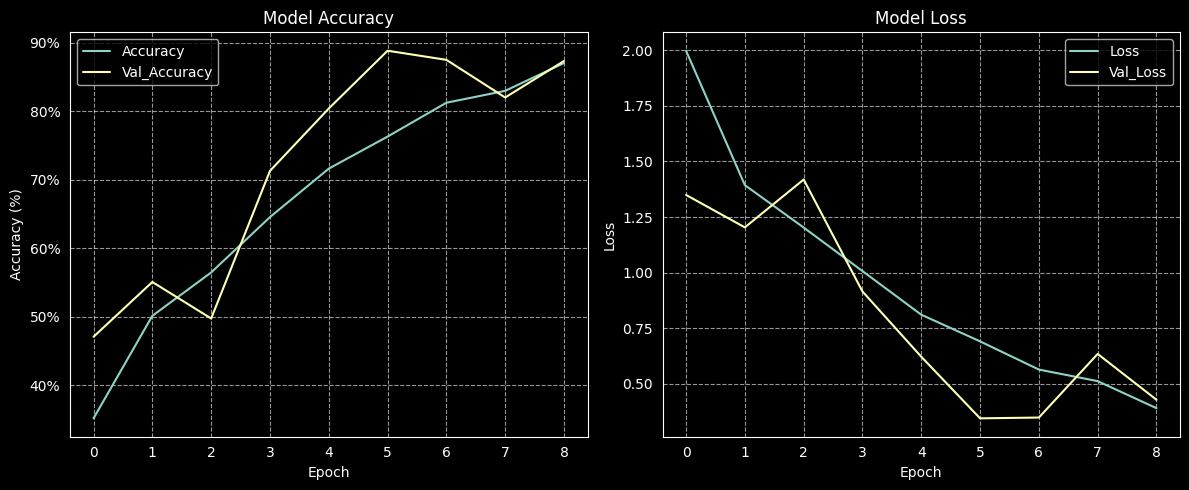

In [29]:

plt.figure(figsize=(12,5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history_cnn.history['accuracy'], label='Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Val_Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')

plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))  # ✅ yüzde format

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history_cnn.history['loss'], label='Loss')
plt.plot(history_cnn.history['val_loss'], label='Val_Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()

# MobileNet

In [30]:
# set to the folder that directly contains the 9 label folders.
src_dir = '/home/groggy/data/a-large-scale-fish-dataset/2/Fish_Dataset/Fish_Dataset'
# set to a NEW output folder where the notebook will copy images,
# removing any subfolders whose name ends with "GT".
clean_dir = '/home/groggy/data/a-large-scale-fish-dataset/2/Fish_Dataset/Fish_Dataset_clean'
# After cleaning, clean_dir should look like:
# <clean_dir>/<Label_i>/<image_files...>

os.makedirs(clean_dir, exist_ok=True)

for label in os.listdir(src_dir):
    label_path = os.path.join(src_dir, label)

    if not os.path.isdir(label_path):
        continue

    dst_label_path = os.path.join(clean_dir, label)
    os.makedirs(dst_label_path, exist_ok=True)

    # 🔥 Traverse subfolders
    for subfolder in os.listdir(label_path):
        sub_path = os.path.join(label_path, subfolder)

        if not os.path.isdir(sub_path):
            continue

        # ❌ Skip folders ending in GT
        if subfolder.endswith("GT"):
            continue

        # ✅ Keep only the real image folder
        if subfolder != label:
            continue

        # 🔥 Copy images from here
        for img_file in os.listdir(sub_path):
            if img_file.lower().endswith(('.jpg','.png','.jpeg')):
                shutil.copy(
                    os.path.join(sub_path, img_file),
                    os.path.join(dst_label_path, img_file)
                )

print("Clean dataset is ready")

Clean dataset is ready


In [31]:
img_size = 224

datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.20
)

train_df, val_df = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=42)

datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen = datagen.flow_from_dataframe(
    train_df,
    x_col='img',
    y_col='label',
    target_size=(224,224),
    class_mode='sparse',
    shuffle=True
)

val_gen = datagen.flow_from_dataframe(
    val_df,
    x_col='img',
    y_col='label',
    target_size=(224,224),
    class_mode='sparse',
    shuffle=False
)

test_gen = datagen.flow_from_dataframe(
    val_df,   # using this temporarily
    x_col='img',
    y_col='label',
    target_size=(224,224),
    class_mode='sparse',
    shuffle=False
)

Found 7200 validated image filenames belonging to 9 classes.
Found 1800 validated image filenames belonging to 9 classes.
Found 1800 validated image filenames belonging to 9 classes.


In [33]:
num_classes = df["label"].nunique()
print("number of classes:", num_classes)

number of classes: 9


In [34]:
# 1. Clear memory (Important!)
tf.keras.backend.clear_session()

# 2. Base Model
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(img_size, img_size, 3))
base_model.trainable = False

# 3. Functional API structure
inputs = Input(shape=(img_size, img_size, 3))
x = base_model(inputs, training=False) # Keep training mode disabled for the frozen base
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
outputs = Dense(num_classes, activation='softmax')(x)

model = Model(inputs, outputs)

# 4. Compile
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(monitor='val_loss',
                           patience=3,
                           restore_best_weights=True)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [35]:
history_MNet = model.fit(train_gen,
                         epochs=10,
                         validation_data=test_gen,
                         callbacks=[early_stop])

Epoch 1/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 151s 646ms/step - accuracy: 0.8094 - loss: 0.6258 - val_accuracy: 0.9861 - val_loss: 0.0995
Epoch 2/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 138s 613ms/step - accuracy: 0.9746 - loss: 0.1150 - val_accuracy: 0.9967 - val_loss: 0.0417
Epoch 3/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 135s 599ms/step - accuracy: 0.9858 - loss: 0.0633 - val_accuracy: 0.9967 - val_loss: 0.0256
Epoch 4/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 135s 598ms/step - accuracy: 0.9922 - loss: 0.0389 - val_accuracy: 0.9978 - val_loss: 0.0186
Epoch 5/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 135s 600ms/step - accuracy: 0.9962 - loss: 0.0273 - val_accuracy: 0.9983 - val_loss: 0.0146
Epoch 6/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 134s 593ms/step - accuracy: 0.9961 - loss: 0.0201 - val_accuracy: 0.9989 - val_loss: 0.0121
Epoch 7/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 132s 584ms/step - accuracy: 0.9967 - loss: 0.0171 - val_accuracy: 0.9994 - val_loss: 0.0100
Epoch 8/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 132s 587ms/step - accuracy: 0.9983 -

In [36]:
model.save("Fish_MN.keras")

# graphics

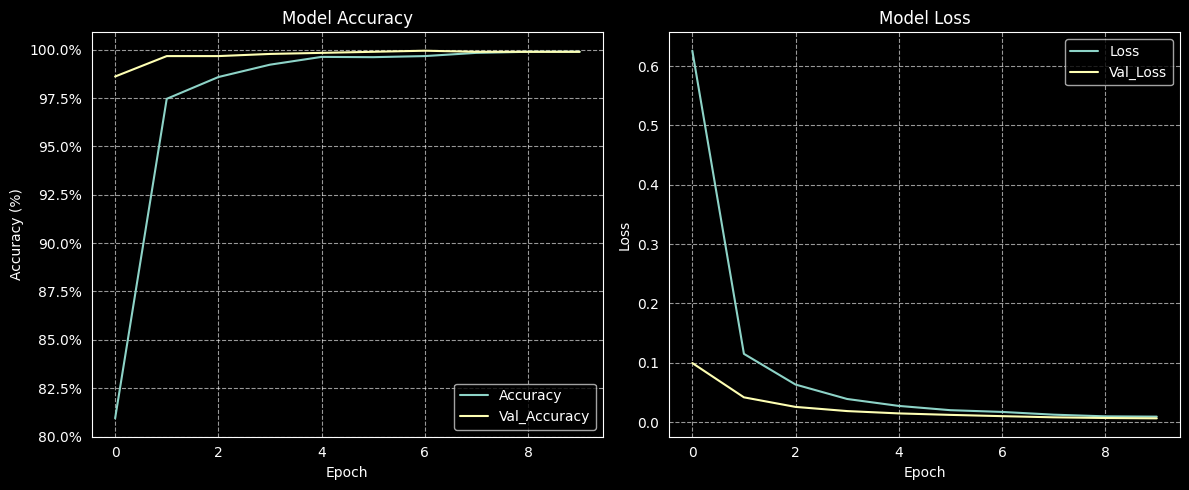

In [37]:
plt.figure(figsize=(12,5))

# Accuracy Plot (%)
plt.subplot(1, 2, 1)
plt.plot(history_MNet.history['accuracy'], label='Accuracy')
plt.plot(history_MNet.history['val_accuracy'], label='Val_Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')

plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))  # ✅ percent format

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history_MNet.history['loss'], label='Loss')
plt.plot(history_MNet.history['val_loss'], label='Val_Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()

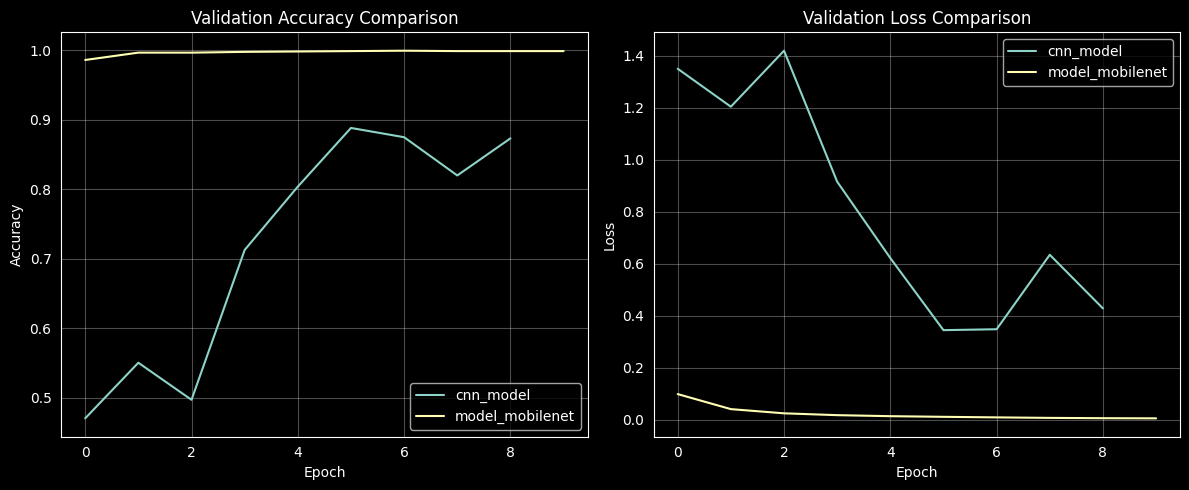

In [38]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history_cnn.history['val_accuracy'], label='cnn_model')
plt.plot(history_MNet.history['val_accuracy'], label='model_mobilenet')

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)

# Loss
plt.subplot(1,2,2)
plt.plot(history_cnn.history['val_loss'], label='cnn_model')
plt.plot(history_MNet.history['val_loss'], label='model_mobilenet')

plt.title("Validation Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

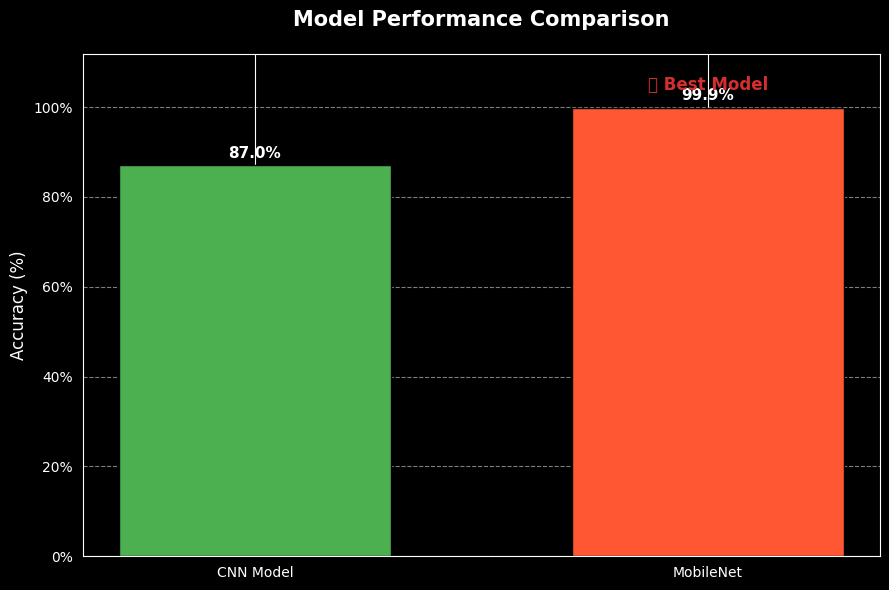

In [39]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Data is taken from training history object
cnn_acc = max(history_cnn.history['accuracy'])
mobilenet_acc = max(history_MNet.history['accuracy'])
models = ['CNN Model', 'MobileNet']
accuracy = [cnn_acc, mobilenet_acc]

plt.figure(figsize=(9, 6))

colors = ['#4CAF50', '#FF5733']
bars = plt.bar(models, accuracy, color=colors, edgecolor='black', width=0.6)

# Y-axis percent formatting
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.title("Model Performance Comparison", fontsize=15, fontweight='bold', pad=20)
plt.ylabel("Accuracy (%)", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Print percentage values on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             yval + 0.01,
             f"{yval*100:.1f}%",
             ha='center', va='bottom', fontsize=11, fontweight='bold')

# Add the "Best Model" label dynamically so it doesn’t overflow
best_idx = accuracy.index(max(accuracy))
plt.text(best_idx, accuracy[best_idx] + 0.04,
         "Best Model",
         ha='center', fontsize=12, color='#D32F2F', fontweight='bold')

# CRITICAL: Set the y-limit dynamically to leave space at the top
plt.ylim(0, max(accuracy) + 0.12)

plt.tight_layout() # Prevent elements from overlapping
plt.show()

# Visualizations testing